In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

In [3]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

In [4]:
import os
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:

corrupted_images = []  # List to store corrupted image paths

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [6]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)



Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


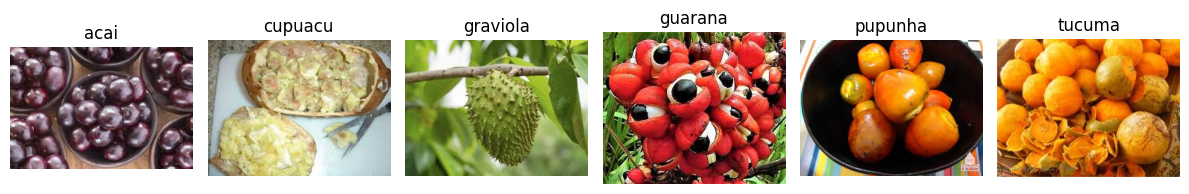

In [7]:


selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
fig, axes = plt.subplots(1,num_classes, figsize=(12,6))

if num_classes == 1:
    axes = [axes]

for ax, img_path, label in zip(axes, selected_images, selected_labels):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
img_height = 224
img_width = 224
batch_size = 64

# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical',
    seed=123
)

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
)

# Normalize datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.


In [9]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [11]:
from tensorflow.keras.layers import LeakyReLU

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,beta_initializer="zeros", gamma_initializer="ones")(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    for filters in [64, 128]:
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,beta_initializer="zeros", gamma_initializer="ones")(x)
        x = LeakyReLU(alpha=0.01)(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,beta_initializer="zeros", gamma_initializer="ones")(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128)(x)
    x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,beta_initializer="zeros", gamma_initializer="ones")(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

# Build & compile model
model = make_model(input_shape=(img_height, img_width, 3), num_classes=num_classes)
model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('best_model_task1.h5', monitor='val_accuracy', save_best_only=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 162,374 (634.27 KB)

 Trainable params: 161,158 (629.52 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [12]:
history = model.fit(
    train_ds,
    epochs=500,
    validation_data=test_ds,
    callbacks=[checkpoint, early_stopping],
)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.1715 - loss: 2.4924

2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 9s/step - accuracy: 0.1662 - loss: 2.4995 - val_accuracy: 0.2333 - val_loss: 1.7913
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 493ms/step - accuracy: 0.3346 - loss: 1.9679 - val_accuracy: 0.2333 - val_loss: 1.7901
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 481ms/step - accuracy: 0.3516 - loss: 1.7084 - val_accuracy: 0.2000 - val_loss: 1.7890
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 486ms/step - accuracy: 0.3012 - loss: 1.7523 - val_accuracy: 0.1667 - val_loss: 1.7889
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.3568 - loss: 1.6450 - val_accuracy: 0.1667 - val_loss: 1.7875
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.3412 - loss: 1.6307 - val_accuracy: 0.1333 - val_loss: 1.7854
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - accuracy: 0.3999 - loss: 1.5297 - val_accuracy: 0.2333 - val_loss: 1.7842
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5479 - loss: 1.2563

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - accuracy: 0.5431 - loss: 1.2661 - val_accuracy: 0.2667 - val_loss: 1.7822
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 0.4578 - loss: 1.5053 - val_accuracy: 0.2667 - val_loss: 1.7821
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4977 - loss: 1.3545

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - accuracy: 0.5022 - loss: 1.3508 - val_accuracy: 0.3000 - val_loss: 1.7803
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.3969 - loss: 1.4781 - val_accuracy: 0.2667 - val_loss: 1.7796
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.5200 - loss: 1.1441 - val_accuracy: 0.2667 - val_loss: 1.7799
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - accuracy: 0.5052 - loss: 1.2908 - val_accuracy: 0.2667 - val_loss: 1.7811
Epoch 14/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.5222 - loss: 1.2284 - val_accuracy: 0.2333 - val_loss: 1.7843
Epoch 15/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.5623 - loss: 1.1836 - val_accuracy: 0.1667 - val_loss: 1.7887
Epoch 16/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step - accuracy: 0.5252 - loss: 1.2307 - val_accuracy: 0.1667 - val_loss: 1.7976
Epoch 17/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 0.6262 - loss: 1.0505 - val_accuracy: 0.1667 - val_lo

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.2667 - loss: 1.7796
Test accuracy: 0.2667
Test loss: 1.7796


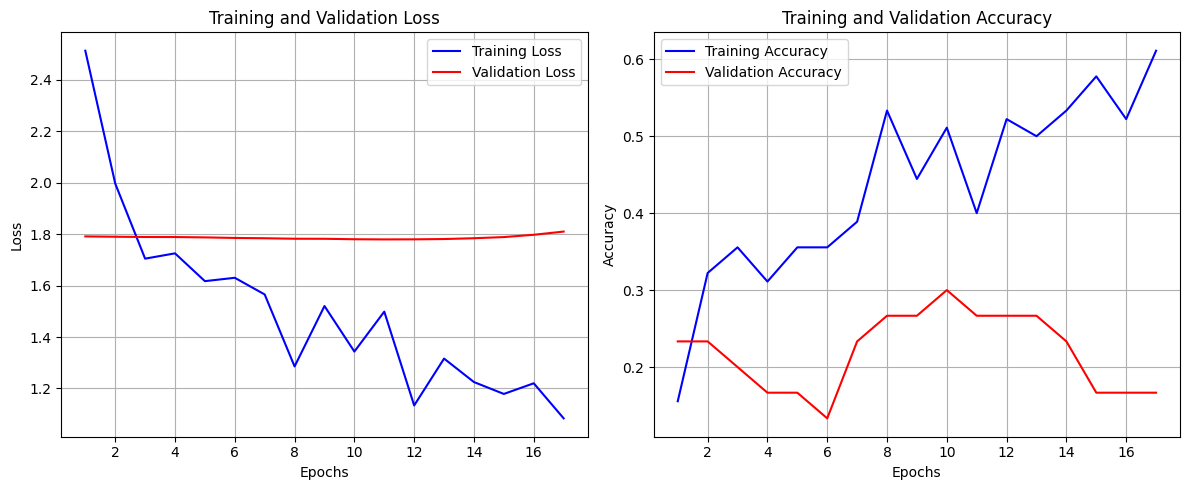

In [14]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

# Create subplots: 1 row, 2 columns
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [15]:
model.save('Sulok_w6_task1.h5')
print("Model saved as 'Sulok_w6_task1.h5'")

Model saved as 'Sulok_w6_task1.h5'


In [18]:

loaded_model = tf.keras.models.load_model('Sulok_w6_task1.h5')
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded model test accuracy: {loaded_test_acc:.4f}")
print(f"Loaded model test loss: {loaded_test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step - accuracy: 0.2667 - loss: 1.7796
Loaded model test accuracy: 0.2667
Loaded model test loss: 1.7796


In [19]:
loaded_model = keras.models.load_model('Sulok_w6_task1.h5')
print("Model loaded for predictions")

# Collect all test images and labels
all_images = []
all_labels = []
for images, labels in test_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

# Concatenate batches into single arrays
test_images = np.concatenate(all_images, axis=0)  # Shape: (30, 128, 128, 3)
test_labels_onehot = np.concatenate(all_labels, axis=0)  # Shape: (30, 6)

# Make predictions
predictions = loaded_model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels_onehot, axis=1)


print(f"Class names: {class_names}")

# Generate classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:\n", report)

Model loaded for predictions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Classification Report:
               precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       1.00      0.40      0.57         5
     guarana       0.00      0.00      0.00         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.19      1.00      0.31         5

    accuracy                           0.27        30
   macro avg       0.36      0.27      0.20        30
weighted avg       0.36      0.27      0.20        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model_vgg = keras.Model(inputs=base_model.input, outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_vgg = model_vgg.fit(
    train_ds,
    epochs=250,
    validation_data=test_ds,
    callbacks=[ModelCheckpoint('best_model_task2.h5', monitor='val_accuracy', save_best_only=True),
               EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1892 - loss: 1.8644 

2/2 ━━━━━━━━━━━━━━━━━━━━ 38s 20s/step - accuracy: 0.2002 - loss: 1.8611 - val_accuracy: 0.4000 - val_loss: 1.7185
Epoch 2/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 436ms/step - accuracy: 0.3708 - loss: 1.6483 - val_accuracy: 0.3667 - val_loss: 1.5661
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 0.5623 - loss: 1.3894 - val_accuracy: 0.4000 - val_loss: 1.5033
Epoch 4/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step - accuracy: 0.7241 - loss: 1.2232 - val_accuracy: 0.3667 - val_loss: 1.4447
Epoch 5/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7984 - loss: 1.0968

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step - accuracy: 0.7990 - loss: 1.0959 - val_accuracy: 0.5667 - val_loss: 1.4077
Epoch 6/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8542 - loss: 0.9862

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - accuracy: 0.8472 - loss: 0.9869 - val_accuracy: 0.6333 - val_loss: 1.3727
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.8316 - loss: 0.8919 - val_accuracy: 0.5000 - val_loss: 1.3647
Epoch 8/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step - accuracy: 0.7737 - loss: 0.8336 - val_accuracy: 0.4333 - val_loss: 1.3093
Epoch 9/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step - accuracy: 0.8138 - loss: 0.7622 - val_accuracy: 0.6000 - val_loss: 1.2683
Epoch 10/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 385ms/step - accuracy: 0.8672 - loss: 0.6847 - val_accuracy: 0.6000 - val_loss: 1.2800
Epoch 11/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step - accuracy: 0.9095 - loss: 0.6440 - val_accuracy: 0.6000 - val_loss: 1.2897
Epoch 12/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - accuracy: 0.9073 - loss: 0.5975 - val_accuracy: 0.6333 - val_loss: 1.2920
Epoch 13/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.9421 - loss: 0.5391 - val_accuracy: 0.5333 - val_loss:

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step - accuracy: 0.9495 - loss: 0.4027 - val_accuracy: 0.6667 - val_loss: 1.1241
Epoch 18/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9543 - loss: 0.3585

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 789ms/step - accuracy: 0.9547 - loss: 0.3619 - val_accuracy: 0.7000 - val_loss: 1.1195
Epoch 19/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.9674 - loss: 0.3426 - val_accuracy: 0.7000 - val_loss: 1.1110
Epoch 20/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.9726 - loss: 0.3038 - val_accuracy: 0.5667 - val_loss: 1.1069
Epoch 21/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.9547 - loss: 0.2996 - val_accuracy: 0.6000 - val_loss: 1.0919
Epoch 22/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step - accuracy: 0.9600 - loss: 0.2701 - val_accuracy: 0.6000 - val_loss: 1.0757
Epoch 23/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.9800 - loss: 0.2566 - val_accuracy: 0.6667 - val_loss: 1.0599
Epoch 24/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step - accuracy: 0.9926 - loss: 0.2318 - val_accuracy: 0.6667 - val_loss: 1.0339
Epoch 25/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.9874 - loss: 0.2213 - val_accuracy: 0.6667 - val_lo

In [22]:
# Evaluate
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_ds)
print(f"Test accuracy for VGG16: {test_acc_vgg:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7000 - loss: 0.9595
Test accuracy for VGG16: 0.7000


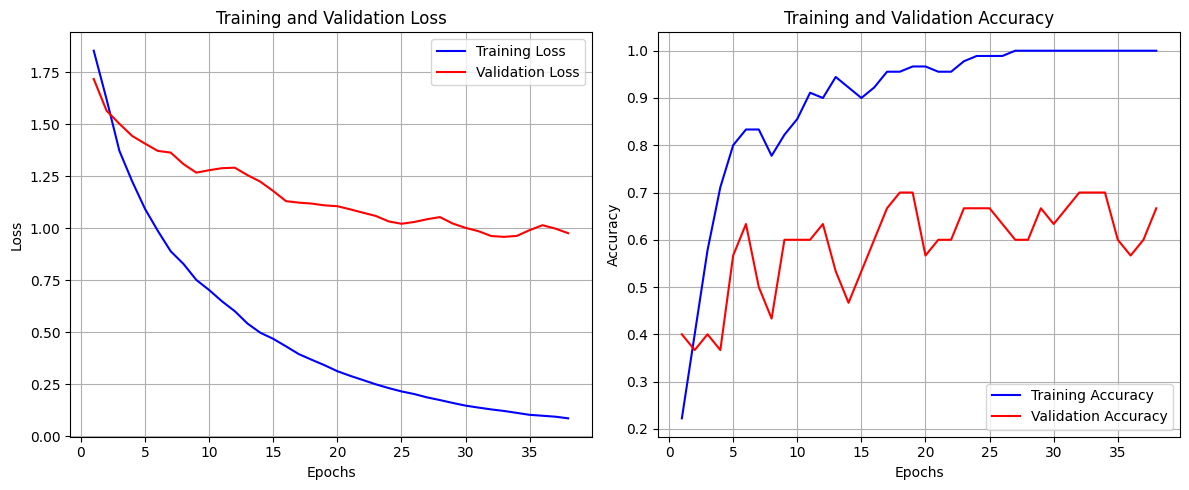

In [23]:
history_dict = history_vgg.history
epochs = range(1, len(history_dict['loss']) + 1)
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

# Create subplots: 1 row, 2 columns
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [24]:

predictions_vgg = model_vgg.predict(test_ds)
y_pred_vgg = np.argmax(predictions_vgg, axis=1)

# Classification Report
print("Classification Report for Task 2 (VGG16):")
print(classification_report(true_labels, y_pred_vgg, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
Classification Report for Task 2 (VGG16):
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.80      0.80      0.80         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.70        30
weighted avg       0.73      0.70      0.70        30



In [25]:
model.save('Sulok_w6_task2.h5')